# Análise quantitativa de casos ruins

## Objetivo

Analisa quantitativamente os casos ruins e compara seu comportamento entre mid e high resolution.

In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent,
    NOTEBOOK_CWD.parent.parent,
):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.project.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment()


In [2]:
from utils.project.notebook_env import get_bad_cases_export_dir, get_default_split_paths
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import utils.comparison_utils.bad_cases as cmp_bad_cases
import utils.visualization as viz
import utils.visualization.bad_cases as viz_bad_cases

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    },
)
plt.close("all")

SPLIT_PATHS_BY_RESOLUTION = get_default_split_paths(REPO_ROOT)

VALID_SPLITS = ("train", "val", "test")


## Carregamento de dados

### Dados dos casos ruins (bad_tests)

## Configuração

Ajuste nesta seção apenas os parâmetros da análise; o pipeline base não é alterado.

In [3]:
bad_cases_split = "test"  # options: "train", "val" or "test"
BAD_CASES_EXPORT_DIR = get_bad_cases_export_dir(REPO_ROOT)

if bad_cases_split not in VALID_SPLITS:
    raise ValueError("bad_cases_split must be 'train', 'val' or 'test'.")
if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["mid_res"]:
    raise ValueError(f"Split '{bad_cases_split}' is not available for mid_res.")

# Cada split é carregado, filtrado e exportado uma única vez.
bad_cases_by_split = {
    split: cmp_bad_cases.prepare_bad_cases_for_subset(
        split_paths_by_resolution=SPLIT_PATHS_BY_RESOLUTION,
        split_name=split,
        output_dir=BAD_CASES_EXPORT_DIR,
        valid_splits=VALID_SPLITS,
    )
    for split in VALID_SPLITS
    if split in SPLIT_PATHS_BY_RESOLUTION["mid_res"]
}

selected_split_data = bad_cases_by_split[bad_cases_split]
df_mid_res = selected_split_data["df_mid"]
df_high_res = selected_split_data["df_high"]
df_mid_bad_res = selected_split_data["df_mid_bad"]
df_high_bad_res = selected_split_data["df_high_bad"]

bad_summary_rows = []
for resolution, summary_df, bad_df, export_info in (
    ("mid_res", df_mid_res, df_mid_bad_res, selected_split_data["mid_export"]),
    ("high_res", df_high_res, df_high_bad_res, selected_split_data["high_export"]),
):
    if summary_df is None:
        continue
    total_cases = int(summary_df.shape[0])
    bad_cases = int(bad_df.shape[0])
    bad_summary_rows.append(
        {
            "resolution": resolution,
            "subset": bad_cases_split,
            "total_cases": total_cases,
            "bad_cases": bad_cases,
            "bad_cases_percent": (
                100 * bad_cases / total_cases if total_cases > 0 else 0.0
            ),
            "csv_path": export_info["csv_path"],
            "json_path": export_info["json_path"],
        }
    )

if df_high_res is None:
    df_high_res = pd.DataFrame(columns=df_mid_res.columns)
    df_high_bad_res = pd.DataFrame(columns=df_mid_bad_res.columns)

bad_summary_df = pd.DataFrame(bad_summary_rows)

## Análise

As subseções abaixo apresentam as métricas, tabelas ou visualizações do objetivo definido.

## Casos Ruins por Subset

### Validação (Val)

#### Carregamento

In [4]:
val_data = bad_cases_by_split["val"]

df_mid_val = val_data["df_mid"]
df_high_val = val_data["df_high"]
df_mid_val_bad = val_data["df_mid_bad"]
df_high_val_bad = val_data["df_high_bad"]
val_mid_export = val_data["mid_export"]
val_high_export = val_data["high_export"]

#### Dice Score dos casos ruins (barra)

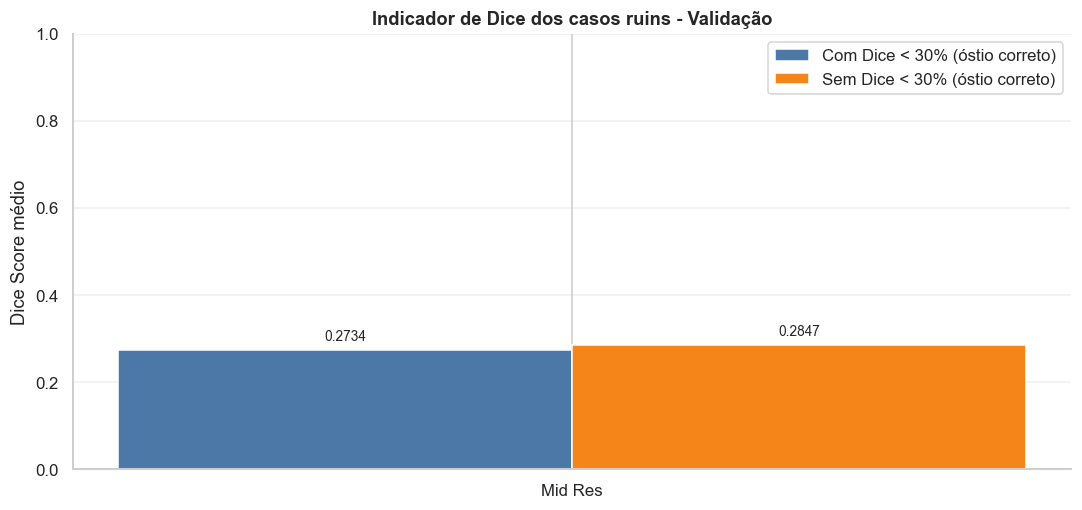

In [5]:
val_bad_dice_indicator_df = viz_bad_cases.plot_bad_dice_indicator(
    df_mid_val_bad,
    df_high_val_bad,
    "Validação",
    summarize_bad_dice_fn=cmp_bad_cases.summarize_bad_dice_with_threshold,
    dice_threshold=0.3,
)

#### Distribuição de casos ruins

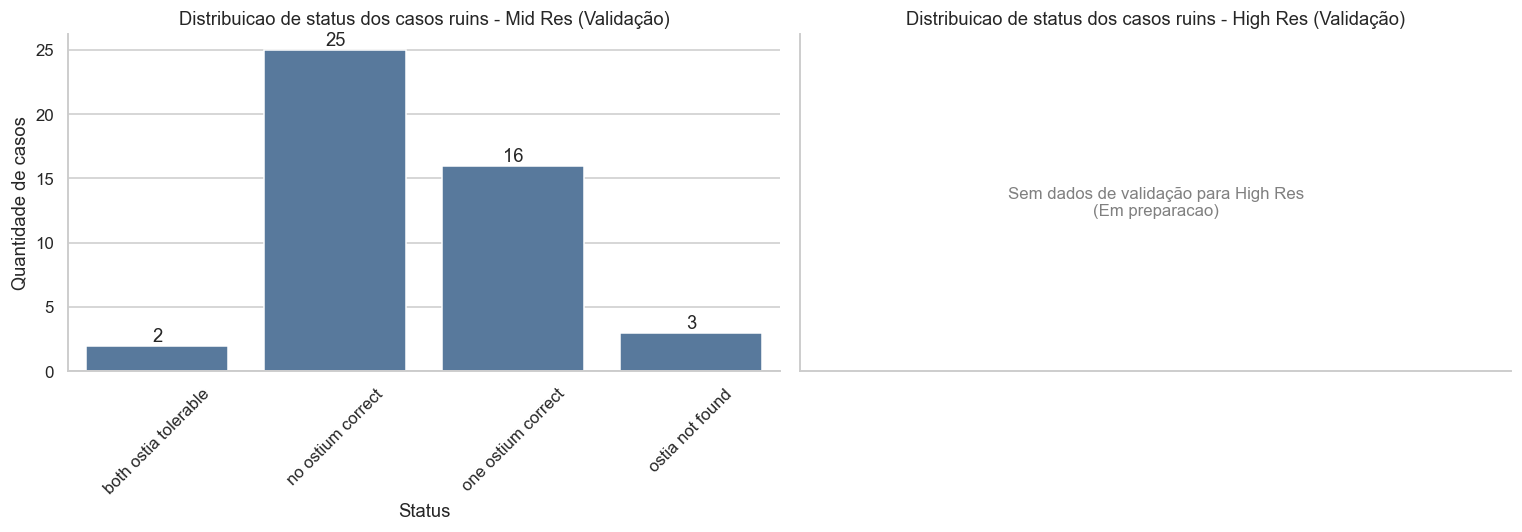

In [6]:
viz.bad_cases.plot_bad_cases_by_subset(
    df_mid_val,
    df_high_val,
    df_mid_val_bad,
    df_high_val_bad,
    "Validação",
)

#### Comparativo entre resoluções (Mid vs High)

In [7]:
val_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_val, df_high_val, "Validação")

### Treino (Train)

#### Carregamento

In [8]:
train_data = bad_cases_by_split["train"]

df_mid_train = train_data["df_mid"]
df_high_train = train_data["df_high"]
df_mid_train_bad = train_data["df_mid_bad"]
df_high_train_bad = train_data["df_high_bad"]
train_mid_export = train_data["mid_export"]
train_high_export = train_data["high_export"]

#### Dice Score dos casos ruins (barra)

,resolution,com_dice_baixo_ok,sem_dice_baixo_ok,n_total_dice,n_removidos_dice_baixo_ok
0,Mid Res,0.487201,0.487201,3,0


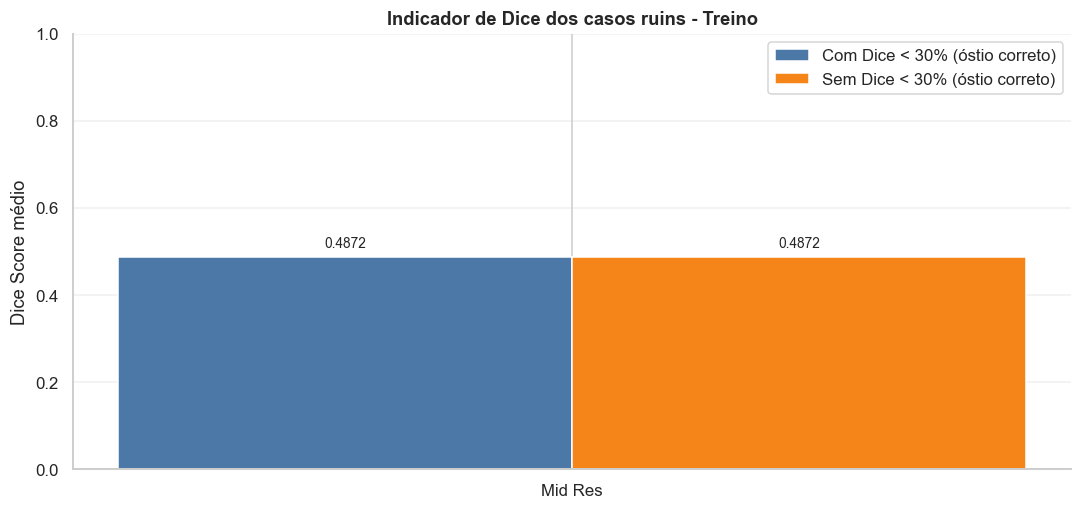

In [9]:
train_bad_dice_indicator_df = viz_bad_cases.plot_bad_dice_indicator(
    df_mid_train_bad,
    df_high_train_bad,
    "Treino",
    summarize_bad_dice_fn=cmp_bad_cases.summarize_bad_dice_with_threshold,
    dice_threshold=0.3,
)
display(train_bad_dice_indicator_df)

#### Distribuição de casos ruins

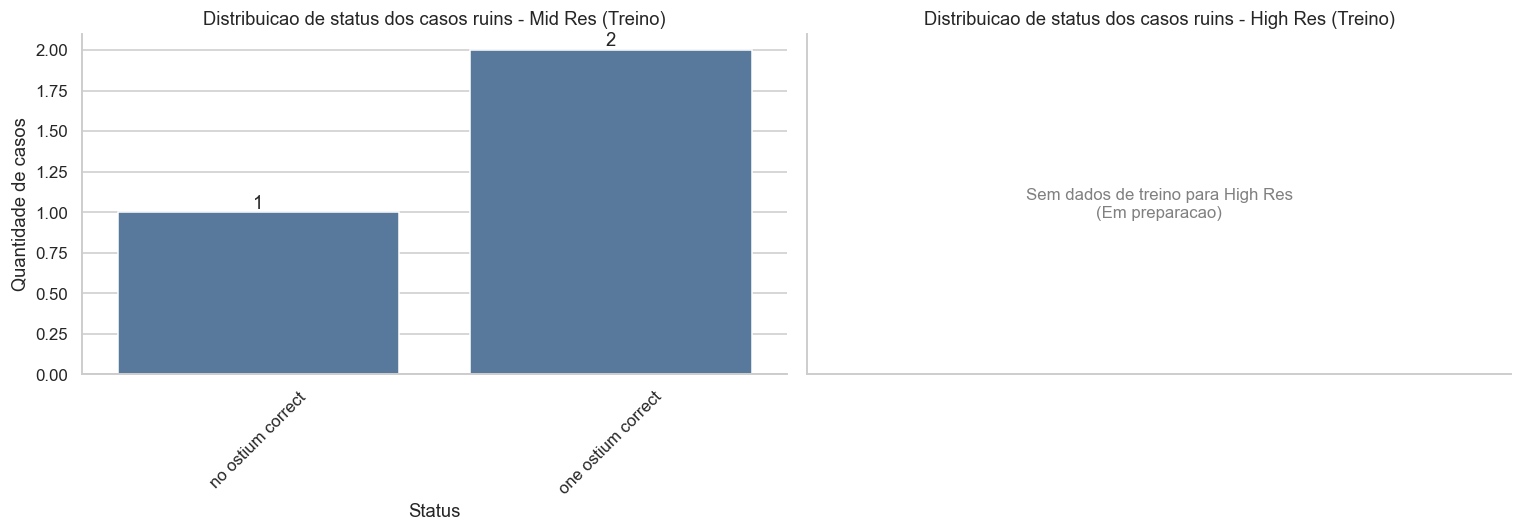

In [10]:
viz.bad_cases.plot_bad_cases_by_subset(df_mid_train, df_high_train, df_mid_train_bad, df_high_train_bad, "Treino")

#### Comparativo entre resoluções (Mid vs High)

In [11]:
train_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_train, df_high_train, "Treino")

### Teste (Test)

#### Carregamento

In [12]:
test_data = bad_cases_by_split["test"]

df_mid_test = test_data["df_mid"]
df_high_test = test_data["df_high"]
df_mid_test_bad = test_data["df_mid_bad"]
df_high_test_bad = test_data["df_high_bad"]
test_mid_export = test_data["mid_export"]
test_high_export = test_data["high_export"]

#### Dice Score dos casos ruins (barra)

,resolution,com_dice_baixo_ok,sem_dice_baixo_ok,n_total_dice,n_removidos_dice_baixo_ok
0,Mid Res,0.28848,0.295789,129,7


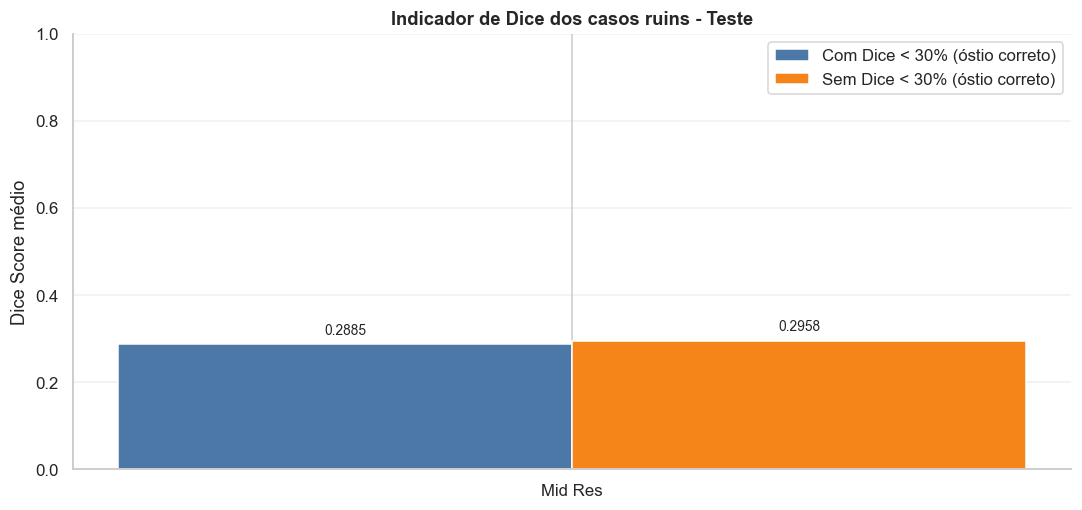

In [13]:
test_bad_dice_indicator_df = viz_bad_cases.plot_bad_dice_indicator(
    df_mid_test_bad,
    df_high_test_bad,
    "Teste",
    summarize_bad_dice_fn=cmp_bad_cases.summarize_bad_dice_with_threshold,
    dice_threshold=0.3,
)
display(test_bad_dice_indicator_df)

#### Distribuição de casos ruins

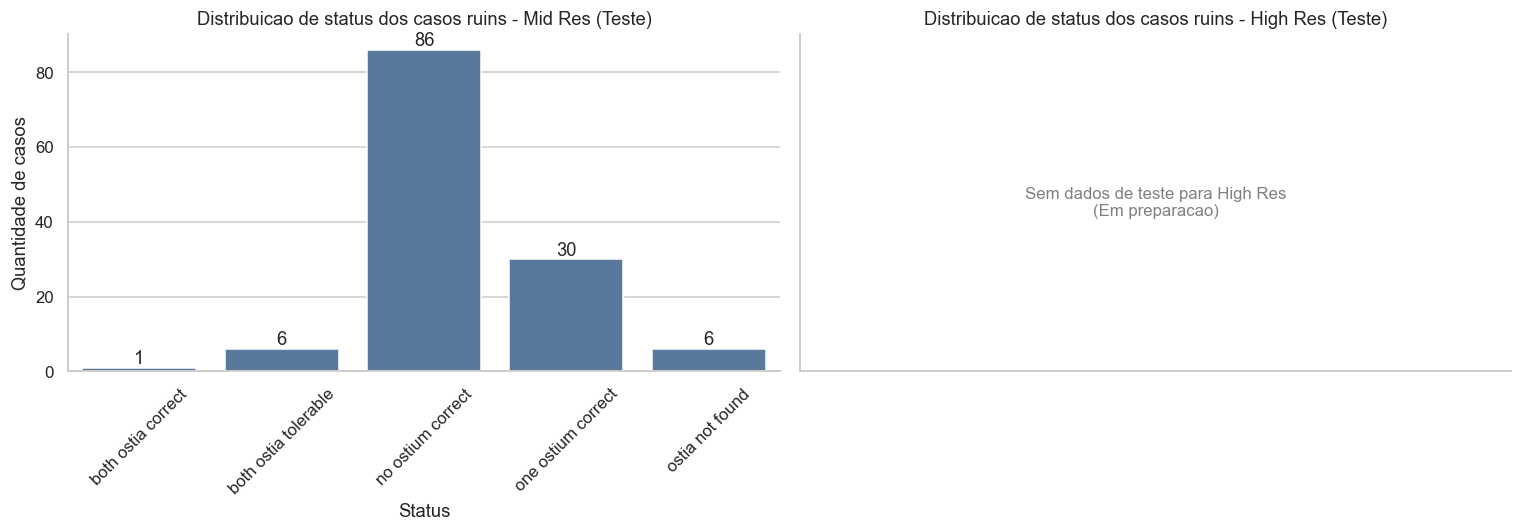

In [14]:
viz.bad_cases.plot_bad_cases_by_subset(df_mid_test, df_high_test, df_mid_test_bad, df_high_test_bad, "Teste")

#### Comparativo entre resoluções (Mid vs High)

In [15]:
test_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_test, df_high_test, "Teste")

## Conclusão

As tabelas identificam os tipos de erro mais frequentes e os exames compartilhados entre resoluções, orientando a seleção da análise qualitativa.